**Name - Arihant Gupta**
<br>
**Enrolment - E23CSEU0055**
<br>
**Batch - EB_02**
<br>
**Date - 02 Sep 2025**
<br>
**Lab - 10**

Dataset Chosen is - Wine Quality - white.csv

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

1.	Read the dataset

In [2]:
df = pd.read_csv("ww.csv", sep=";")
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5        6  
2     10.1        6 

2.	Extract the Independent and Dependent Variable.

In [3]:
x = df.drop('quality', axis=1)
y = df['quality']

3.	Convert the Output column quality (score between 0 and 10) into the three categories i.e., best, average, and poor.  

In [15]:
bins = [0, 4.5, 6.5, 10]
labels = ['poor', 'average', 'best']
ny = pd.cut(y, bins=bins, labels=labels, right=True)
print(ny)

0       average
1       average
2       average
3       average
4       average
         ...   
4893    average
4894    average
4895    average
4896       best
4897    average
Name: quality, Length: 4898, dtype: category
Categories (3, object): ['poor' < 'average' < 'best']


4.	Split the dataset into training and testing using 75-25 division.

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, ny, test_size=0.25, random_state=42)

5.	Perform normalization on numerical features

In [6]:
scaler = StandardScaler()
xtrs = scaler.fit_transform(x_train)
xtes = scaler.transform(x_test)

6.	Build a Random Forest classification model using Sklearn with default parameters. Predict the target values in the testing set.

In [16]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(xtrs, y_train)
y_pred_rf = rf_model.predict(xtes)
print(y_pred_rf)

['best' 'best' 'best' ... 'best' 'best' 'average']


7.	Check the performance of model using confusion matrix.

Random Forest Confusion Matrix:


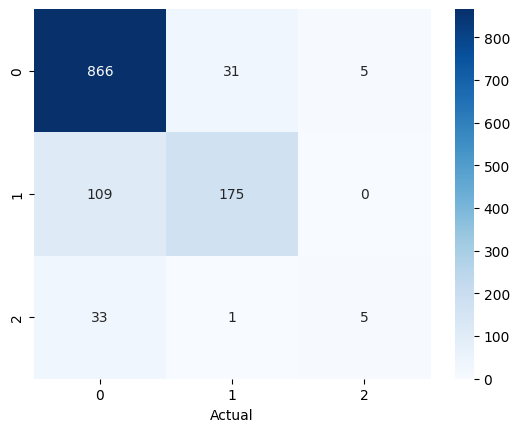

In [14]:
print("Random Forest Confusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Actual")
plt.ylabel("Pre")
plt.show()

8.	Calculate the accuracy, Precision, Recall and F1-score.

In [9]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
print("\nRandom Forest Metrics:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")


Random Forest Metrics:
Accuracy: 0.8539
Precision: 0.8445
Recall: 0.8539
F1-Score: 0.8395


In [10]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(xtrs, y_train)
y_pred_dt = dt_model.predict(xtes)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print("\nDecision Tree Metrics:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")


Decision Tree Metrics:
Accuracy: 0.7967
Precision: 0.8002
Recall: 0.7967
F1-Score: 0.7984


9.	Compare the performance of the Random Forest model with Decision Tree Model.

In [11]:
print("\nModel Performance Comparison:")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")


Model Performance Comparison:
Random Forest Accuracy: 0.8539
Decision Tree Accuracy: 0.7967
